Given snapshot data, we aim to train a MPS that produce the probability distribution. We use Ising model and snapshot in z basis as example. Note that the ground state wavefunction is "stoquastic", i.e. real and positive, so it's expected that the trained MPS can be used to approximate the original quantum many-body wavefunction.

First we generate the snapshot data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tenpy
import MPSToolBox as my

Imported MPSToolBox


In [2]:
psi = my.load_pkl("../wavefunctions/CritIsingModel_L20_chi300_PBC_.pkl")

In [3]:
N = 10000
for i in range(N):
    s_i, _ = psi.sample_measurements()
    if i == 0:
        s = [s_i]
    else:
        s.append(s_i)
data = np.array(s)
np.save(f'temp/CritIsing_L{psi.L}_Zsnapshots_N{N}.npy', data)

Load data and code for training

In [17]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import quimb.tensor as qtn

In [2]:
L = 20
N = 10000
data = np.load(f'temp/CritIsing_L{L}_Zsnapshots_N{N}.npy')
data = data * 2 - 1  # convert to +/-1 representation

In [3]:
import numpy as np

def spins_to_bits(samples: np.ndarray) -> np.ndarray:
    """
    Map samples to {0,1} with shape (N,L).
    Accepts either {-1,+1} or {0,1}.
    """
    samples = np.asarray(samples)
    uniq = np.unique(samples)
    if np.all(np.isin(uniq, [-1, 1])):
        return ((samples + 1) // 2).astype(np.int64)
    if np.all(np.isin(uniq, [0, 1])):
        return samples.astype(np.int64)
    raise ValueError(f"Expected samples in {{-1,+1}} or {{0,1}}, got values {uniq}")

def random_cyclic_shifts(samples01: np.ndarray, rng=None) -> np.ndarray:
    """
    Apply a random cyclic shift to each sample to respect periodic invariance.
    """
    if rng is None:
        rng = np.random.default_rng()
    N, L = samples01.shape
    shifts = rng.integers(0, L, size=N)
    out = np.empty_like(samples01)
    for i in range(N):
        out[i] = np.roll(samples01[i], shifts[i])
    return out


In [48]:
def quimb_mps_from_torch(L, D, device="cpu", dtype=torch.float64):
    # Create a random OBC MPS, then move the raw arrays onto torch.
    mps = qtn.MPS_rand_state(L, bond_dim=D, phys_dim=2, cyclic=False, dtype="float64")

    def to_torch(x):
        return torch.tensor(x, device=device, dtype=dtype, requires_grad=True)

    mps.apply_to_arrays(to_torch)
    return mps

def mps_amplitudes_quimb(mps, x01_batch):
    # x01_batch: (B,L) torch long or int
    # quimb expects a list/tuple of ints for one config
    amps = []
    xb = x01_batch.detach().cpu().numpy().astype(int)
    for x in xb:
        amps.append(mps.amplitude(tuple(x)))
    return torch.stack(amps)

def norm_sq_quimb(mps):
    # inner product <psi|psi>
    # quimb returns a torch scalar since all arrays live on torch tensors
    return (mps.H @ mps)

def nll_quimb_born(mps, x01_batch, eps=1e-12):
    psi = mps_amplitudes_quimb(mps, x01_batch)
    log_norm = torch.log(norm_sq_quimb(mps) + eps)
    log_prob = 2.0 * torch.log(torch.abs(psi) + eps) - log_norm
    return -log_prob.mean()

@torch.no_grad()
def exp_beta_sumZ_quimb(mps, beta):
    """
    Compute <exp(beta sum Z)> exactly by inserting local operator exp(beta Z).
    bit 0 -> Z=-1, bit 1 -> Z=+1.
    So exp(beta Z) = diag(exp(-beta), exp(+beta)).
    """
    import math
    op = torch.tensor([[math.exp(-beta), 0.0],
                       [0.0, math.exp(+beta)]], dtype=mps.arrays[0].dtype, device=mps.arrays[0].device)

    # Build an MPO which is product of local ops: apply op on every site
    # For product operators, easiest is to apply gates to copy and take norm overlap:
    psi = mps.copy()
    for i in range(mps.L):
        psi.gate_(op, where=i)

    num = (mps.H @ psi)
    den = (mps.H @ mps)
    return (num / den).item()

def train_quimb(data_np, D=32, batch_size=256, lr=1e-3, epochs=50, device="cpu"):
    losslist = []
    data01 = spins_to_bits(data_np)
    N, L = data01.shape

    x = torch.tensor(data01, dtype=torch.long)
    ds = TensorDataset(x)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    mps = quimb_mps_from_torch(L, D, device=device)
    opt = torch.optim.Adam(mps.arrays, lr=lr)

    rng = np.random.default_rng(0)

    for ep in range(epochs):
        for (xb,) in loader:
            xb_np = random_cyclic_shifts(xb.numpy(), rng=rng)
            xb = torch.tensor(xb_np, dtype=torch.long, device=device)

            loss = nll_quimb_born(mps, xb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        if (ep + 1) % 1 == 0:
            # S_half = mps_entropy_half_cpu(mps, L // 2)
            # val = exp_beta_sumZ_quimb(mps, beta=0.1)
            print(f"epoch {ep+1:4d}  nll={loss.item():.4f}")
            losslist.append(loss.item())
    return mps, np.array(losslist)


In [53]:
# Uniform (parameter-shared) MPS training for OBC data
# Note: quimb only offers translationally invariant random states via trans_invar with cyclic=True,
# so we build an OBC uniform ansatz by sharing a single bulk tensor and two boundary vectors.
def build_uniform_mps_params(D, device="cpu", dtype=torch.float64):
    A = torch.randn(D, D, 2, device=device, dtype=dtype, requires_grad=True)  # bulk tensor (l, r, p)
    lvec = torch.randn(D, device=device, dtype=dtype, requires_grad=True)      # left boundary vector
    rvec = torch.randn(D, device=device, dtype=dtype, requires_grad=True)      # right boundary vector
    return A, lvec, rvec

def uniform_mps_from_params(A, lvec, rvec, L):
    assert L >= 2, "This simple helper assumes L >= 2."
    arrays = []
    # first site: contract left boundary into bulk tensor -> shape (bond_dim, phys_dim) with order 'rp'
    arrays.append(torch.tensordot(lvec, A, dims=([0], [0])))
    # bulk sites share the same tensor
    for _ in range(L - 2):
        arrays.append(A)
    # last site: contract bulk tensor into right boundary -> shape (bond_dim, phys_dim) with order 'lp'
    arrays.append(torch.tensordot(A, rvec, dims=([1], [0])))
    return qtn.MatrixProductState(arrays, shape="lrp")

def mps_entropy_half_cpu(mps, cut):
    """Compute entanglement entropy safely: move to CPU/numpy and canonicalize."""
    mps_cpu = mps.copy()
    # bring raw arrays to numpy on CPU for quimb's SVD routines
    mps_cpu.apply_to_arrays(lambda x: x.detach().cpu().numpy())
    # canonicalize and normalize so singular values form a probability distribution
    mps_cpu.left_canonicalize_(normalize=True)
    return float(mps_cpu.entropy(cut))

def train_uniform_mps(data_np, D=16, batch_size=256, lr=1e-3, epochs=50, device="cpu", dtype=torch.float64):
    losslist = []
    data01 = spins_to_bits(data_np)
    N, L = data01.shape

    x = torch.tensor(data01, dtype=torch.long)
    ds = TensorDataset(x)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    A, lvec, rvec = build_uniform_mps_params(D, device=device, dtype=dtype)
    opt = torch.optim.Adam([A, lvec, rvec], lr=lr)

    eval_x = torch.tensor(data01[: min(1024, N)], dtype=torch.long, device=device)

    for ep in range(epochs):
        for (xb,) in loader:
            xb = xb.to(device)
            mps = uniform_mps_from_params(A, lvec, rvec, L)
            loss = nll_quimb_born(mps, xb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        with torch.no_grad():
            mps_eval = uniform_mps_from_params(A, lvec, rvec, L)
            loss_eval = nll_quimb_born(mps_eval, eval_x).item()
            # S_half = mps_entropy_half_cpu(mps_eval, L // 2)
            print(f"epoch {ep+1:4d}  loss={loss_eval:.6f}")
            losslist.append(loss_eval)

    return A, lvec, rvec, mps_eval, np.array(losslist)


epoch    1  nll=10.1983
epoch    2  nll=9.8506
epoch    3  nll=10.2979
epoch    4  nll=10.2073
epoch    5  nll=9.8142
epoch    6  nll=10.4935
epoch    7  nll=9.7246
epoch    8  nll=10.4099
epoch    9  nll=10.0281
epoch   10  nll=10.1340
epoch   11  nll=9.9769
epoch   12  nll=9.7681
epoch   13  nll=9.3487
epoch   14  nll=9.9574
epoch   15  nll=9.8919
epoch   16  nll=9.4415
epoch   17  nll=10.4951
epoch   18  nll=10.7225
epoch   19  nll=10.5475
epoch   20  nll=10.2615
epoch   21  nll=9.7411
epoch   22  nll=9.4353
epoch   23  nll=9.5575
epoch   24  nll=9.3142
epoch   25  nll=9.2702
epoch   26  nll=9.5081
epoch   27  nll=9.1014
epoch   28  nll=9.7798
epoch   29  nll=9.5206
epoch   30  nll=9.1485
epoch   31  nll=9.1215
epoch   32  nll=9.4539
epoch   33  nll=9.0713
epoch   34  nll=9.3371
epoch   35  nll=9.2668
epoch   36  nll=8.8590
epoch   37  nll=9.3144
epoch   38  nll=9.1481
epoch   39  nll=9.7344
epoch   40  nll=9.3258
epoch   41  nll=9.4629
epoch   42  nll=8.9630
epoch   43  nll=9.2004


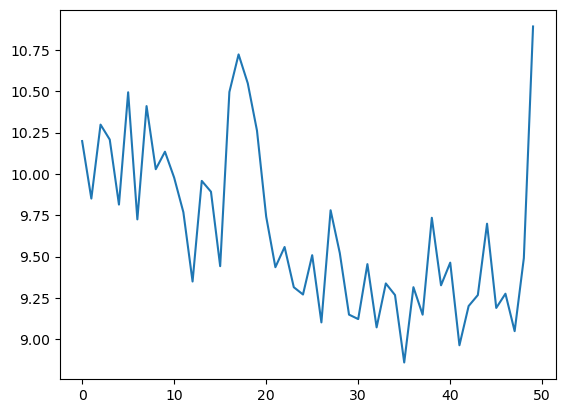

In [50]:
mps, losslist = train_quimb(data, D=8, batch_size=256, lr=1e-2, epochs=50, device="cuda")
plt.plot(losslist)

epoch    1  nll=11.1365
epoch    2  nll=11.2323
epoch    3  nll=11.2661
epoch    4  nll=11.3728
epoch    5  nll=10.6178
epoch    6  nll=10.8816
epoch    7  nll=11.5016
epoch    8  nll=10.6314
epoch    9  nll=11.7750
epoch   10  nll=10.6787
epoch   11  nll=10.2449
epoch   12  nll=10.8134
epoch   13  nll=10.3089
epoch   14  nll=10.2504
epoch   15  nll=11.7901
epoch   16  nll=11.3987
epoch   17  nll=10.5844
epoch   18  nll=11.2997
epoch   19  nll=10.3967
epoch   20  nll=10.2428
epoch   21  nll=9.6617
epoch   22  nll=10.0842
epoch   23  nll=10.1716
epoch   24  nll=9.3977
epoch   25  nll=9.5548
epoch   26  nll=9.5260
epoch   27  nll=9.5595
epoch   28  nll=11.6390
epoch   29  nll=10.4504
epoch   30  nll=10.7554
epoch   31  nll=9.8462
epoch   32  nll=9.7689
epoch   33  nll=9.5817
epoch   34  nll=9.5254
epoch   35  nll=10.1057
epoch   36  nll=9.8453
epoch   37  nll=9.6056
epoch   38  nll=9.7380
epoch   39  nll=9.5802
epoch   40  nll=9.0641
epoch   41  nll=9.6027
epoch   42  nll=9.1665
epoch   

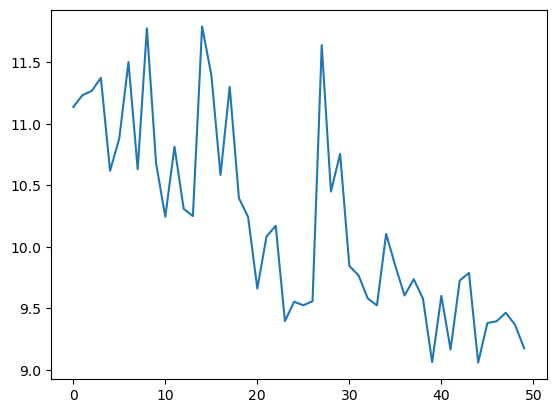

In [56]:
mps, losslist = train_quimb(data, D=16, batch_size=256, lr=1e-2, epochs=50, device="cuda")
plt.plot(losslist)

epoch    1  nll=14.3432
epoch    2  nll=14.0668
epoch    3  nll=13.3792
epoch    4  nll=12.7333
epoch    5  nll=12.3395
epoch    6  nll=12.6846
epoch    7  nll=12.6507
epoch    8  nll=12.3964
epoch    9  nll=11.9431
epoch   10  nll=12.1466
epoch   11  nll=12.1080
epoch   12  nll=11.5324
epoch   13  nll=11.5248
epoch   14  nll=11.1671
epoch   15  nll=11.3718
epoch   16  nll=11.5413
epoch   17  nll=11.2437
epoch   18  nll=10.9914
epoch   19  nll=11.3203
epoch   20  nll=11.2599
epoch   21  nll=11.3505
epoch   22  nll=11.1055
epoch   23  nll=11.2355
epoch   24  nll=11.1199
epoch   25  nll=10.9925
epoch   26  nll=11.4557
epoch   27  nll=10.6990
epoch   28  nll=10.8831
epoch   29  nll=11.0041
epoch   30  nll=10.8744
epoch   31  nll=11.0907
epoch   32  nll=11.5319
epoch   33  nll=10.6765
epoch   34  nll=10.9942
epoch   35  nll=10.9492
epoch   36  nll=10.9665
epoch   37  nll=10.7006
epoch   38  nll=10.6243
epoch   39  nll=10.8048
epoch   40  nll=10.8641
epoch   41  nll=11.2103
epoch   42  nll=

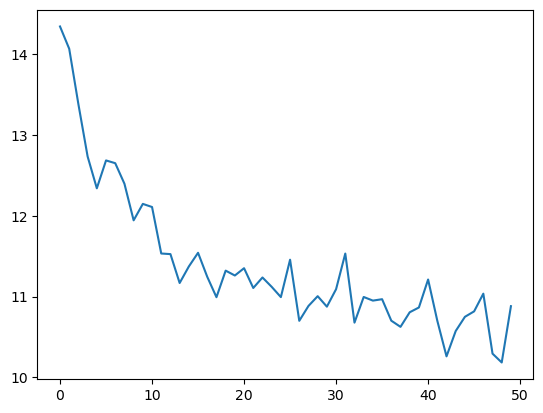

In [51]:
mps, losslist = train_quimb(data, D=8, batch_size=256, lr=1e-3, epochs=50, device="cuda")
plt.plot(losslist)

epoch    1  nll=12.8443
epoch    2  nll=12.4361
epoch    3  nll=12.0628
epoch    4  nll=11.4666
epoch    5  nll=11.1813
epoch    6  nll=11.3546
epoch    7  nll=11.5814
epoch    8  nll=11.1324
epoch    9  nll=11.1569
epoch   10  nll=11.2319
epoch   11  nll=11.1958
epoch   12  nll=11.2606
epoch   13  nll=11.0464
epoch   14  nll=11.0328
epoch   15  nll=10.8603
epoch   16  nll=10.9224
epoch   17  nll=11.6332
epoch   18  nll=11.3118
epoch   19  nll=11.0164
epoch   20  nll=11.0280
epoch   21  nll=11.0635
epoch   22  nll=10.9848
epoch   23  nll=11.0061
epoch   24  nll=11.1719
epoch   25  nll=10.7555
epoch   26  nll=10.5350
epoch   27  nll=10.7601
epoch   28  nll=10.8235
epoch   29  nll=11.1349
epoch   30  nll=10.7954
epoch   31  nll=10.5336
epoch   32  nll=10.5102
epoch   33  nll=10.5692
epoch   34  nll=10.8446
epoch   35  nll=10.5952
epoch   36  nll=10.6279
epoch   37  nll=10.3841
epoch   38  nll=10.7739
epoch   39  nll=10.3499
epoch   40  nll=10.5427
epoch   41  nll=10.0790
epoch   42  nll=

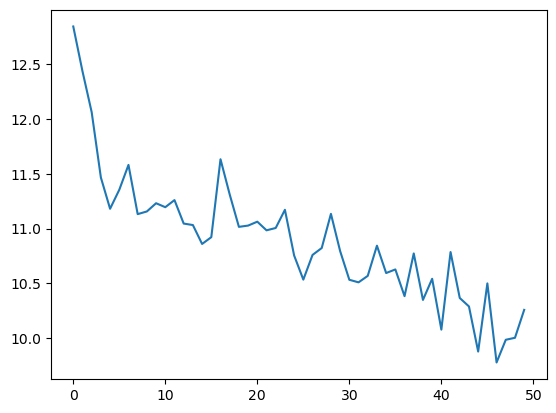

In [55]:
mps, losslist = train_quimb(data, D=16, batch_size=256, lr=1e-3, epochs=50, device="cuda")
plt.plot(losslist)

In [52]:
_, _, _, mps, losslist = train_uniform_mps(data, D=8, batch_size=256, lr=1e-2, epochs=50, device="cuda", dtype=torch.float64)
plt.plot(losslist)

epoch    1  loss=13.086079
epoch    2  loss=11.411572
epoch    3  loss=11.293617
epoch    4  loss=10.830889
epoch    5  loss=10.601241
epoch    6  loss=10.348560
epoch    7  loss=10.750769
epoch    8  loss=10.853693
epoch    9  loss=10.758672
epoch   10  loss=10.889992
epoch   11  loss=10.833385
epoch   12  loss=10.673986
epoch   13  loss=10.635476
epoch   14  loss=10.716509
epoch   15  loss=10.558510
epoch   16  loss=10.572874
epoch   17  loss=10.460501
epoch   18  loss=10.345087
epoch   19  loss=10.286059
epoch   20  loss=10.280412
epoch   21  loss=10.261543
epoch   22  loss=10.328774
epoch   23  loss=10.370658
epoch   24  loss=10.277324
epoch   25  loss=10.434616
epoch   26  loss=10.661591
epoch   27  loss=11.078810
epoch   28  loss=10.869313
epoch   29  loss=10.599573
epoch   30  loss=10.742946
epoch   31  loss=10.659033
epoch   32  loss=10.674940
epoch   33  loss=11.136719
epoch   34  loss=10.860725
epoch   35  loss=10.710300
epoch   36  loss=10.630826
epoch   37  loss=10.528659
e

ValueError: not enough values to unpack (expected 5, got 4)

epoch    1  loss=15.963600
epoch    2  loss=15.899753
epoch    3  loss=15.866584
epoch    4  loss=15.845696
epoch    5  loss=15.800563
epoch    6  loss=15.751351
epoch    7  loss=15.697537
epoch    8  loss=15.671105
epoch    9  loss=15.616930
epoch   10  loss=15.597853
epoch   11  loss=15.557978
epoch   12  loss=15.516726
epoch   13  loss=15.494961
epoch   14  loss=15.476940
epoch   15  loss=15.351868
epoch   16  loss=15.333070
epoch   17  loss=15.313478
epoch   18  loss=15.296304
epoch   19  loss=15.279564
epoch   20  loss=15.220270
epoch   21  loss=15.196218
epoch   22  loss=15.156260
epoch   23  loss=15.122152
epoch   24  loss=15.086669
epoch   25  loss=15.266109
epoch   26  loss=14.906723
epoch   27  loss=14.856673
epoch   28  loss=14.867026
epoch   29  loss=14.843478
epoch   30  loss=14.825209
epoch   31  loss=14.759272
epoch   32  loss=14.759264
epoch   33  loss=14.734336
epoch   34  loss=14.708821
epoch   35  loss=14.688486
epoch   36  loss=14.645162
epoch   37  loss=14.638200
e

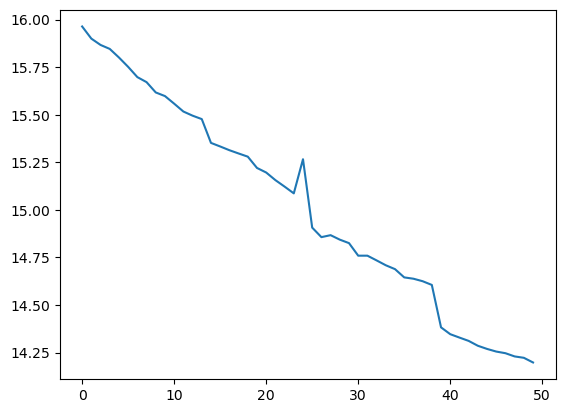

In [54]:
_, _, _, mps, losslist = train_uniform_mps(data, D=8, batch_size=256, lr=1e-3, epochs=50, device="cuda", dtype=torch.float64)
plt.plot(losslist)

epoch    1  loss=14.263416
epoch    2  loss=13.884711
epoch    3  loss=13.845446
epoch    4  loss=13.781552
epoch    5  loss=13.921884
epoch    6  loss=13.876728
epoch    7  loss=13.884847
epoch    8  loss=13.830835
epoch    9  loss=13.816856
epoch   10  loss=13.794355
epoch   11  loss=13.757128
epoch   12  loss=13.683486
epoch   13  loss=13.632244
epoch   14  loss=13.628517
epoch   15  loss=13.721459
epoch   16  loss=13.673459
epoch   17  loss=13.636574
epoch   18  loss=13.592536
epoch   19  loss=13.559772
epoch   20  loss=13.512393
epoch   21  loss=13.420326
epoch   22  loss=13.529944
epoch   23  loss=13.395759
epoch   24  loss=13.371160
epoch   25  loss=13.343478
epoch   26  loss=13.323894
epoch   27  loss=13.274718
epoch   28  loss=13.244635
epoch   29  loss=13.226208
epoch   30  loss=13.199128
epoch   31  loss=13.184493
epoch   32  loss=13.170669
epoch   33  loss=13.153276
epoch   34  loss=13.160427
epoch   35  loss=13.131039
epoch   36  loss=13.112134
epoch   37  loss=13.082450
e

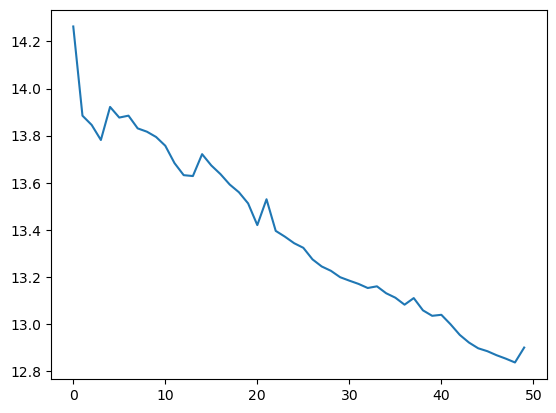

In [57]:
_, _, _, mps, losslist = train_uniform_mps(data, D=16, batch_size=256, lr=1e-3, epochs=50, device="cuda", dtype=torch.float64)
plt.plot(losslist)

In [45]:
mps_cpu = mps.copy()
mps_cpu.apply_to_arrays(lambda x: x.detach().cpu().numpy())
mps_cpu.left_canonicalize_(normalize=True)

MatrixProductState(tensors=20, indices=39, L=20, max_bond=8)

In [46]:
y = [mps_cpu.entropy(i) for i in range(1, mps_cpu.L)]

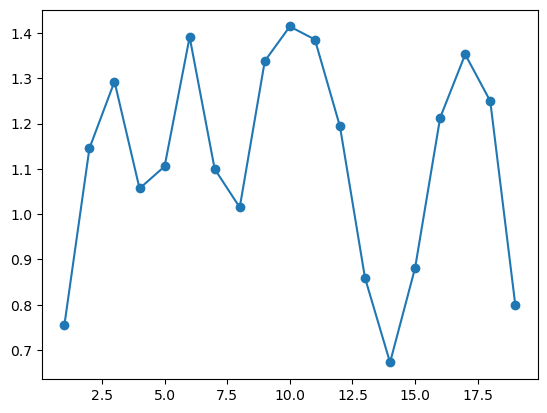

In [47]:
plt.plot(range(1, mps_cpu.L), y, marker='o')

In [31]:
import torch
import math

Z = torch.tensor([[-1.0, 0.0],
                  [ 0.0, 1.0]], dtype=mps.arrays[0].dtype, device=mps.arrays[0].device)

# Two-point <Z_i Z_j>
def ZZ(mps, i, j):
    psi = mps.copy()
    psi.gate_(Z, where=i)
    psi.gate_(Z, where=j)
    return ((mps.H @ psi) / (mps.H @ mps)).item()


[1.0000000000000002, 0.6207018348060306, 0.36595685496390823, 0.5164152730747802, 0.3031473447913283, 0.34968244680044835, 0.32541210100936585, 0.19828604123110807, 0.11888988600272828, 0.060021330254360114, 0.06568268593369879, 0.06496489426377335, 0.07549005994341478, 0.04377757181346615, 0.01248259685427615, 0.018777661529536863, 0.017869992342446905, 0.006810678740062403, 0.003088582455480864, 0.0059950570242998475]


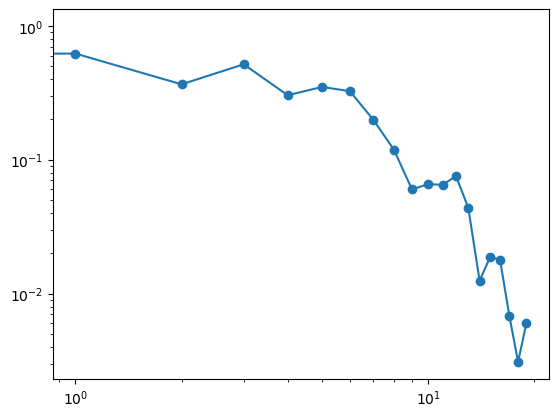

In [44]:
y = [ZZ(mps, 0,i) for i in range(mps.L)]
print(y)
x = range(mps.L)
x_chord = [math.sin(math.pi * i / mps.L) for i in range(mps.L)]
plt.plot(x, y, marker='o')
plt.xscale('log')
plt.yscale('log')